In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()


## Textbooks vs. Computers

One confusing aspect of statistical computing is that often there is a disconnect between what is printed in a statistical computing textbook and what *should* be implemented on the computer. In textbooks, it is usually simpler to present solutions as convenient mathematical formulas whenever possible, in order to communicate basic ideas and to provide some insight. However, directly translating these formulas into computer code is usually not advisable because there are many problematic aspects of computers that are simply not relevant when writing things down on paper.

Some key issues to look for when implementing statistical or numerical solutions on the computer are

1. Overflow - When numbers get too big, they cannot be represented on a computer and so often `NA`s are produced instead;
2. Underflow - Similar to overflow, numbers can get too small for computers to represent, resulting in errors or warnings or inaccurate computation;
3. Near linear dependence - the existence of linear dependence in matrix computations depends on the precision of a machine. Because computers are finite precision, there are commonly situations where one might think there is no linear dependence but the computer cannot tell the difference.

All three of the above problems arise from the finite precision nature of all computers. One must take care to use algorithms that do calculations in the computable range and that automatically handle things like near dependence.

Below, I highlight some common examples in statistics where the implementation diverges from what textbooks explain as the solution: Computing with logarithms, the least squares solution to the linear regression estimation problem, and the computation of the multivariate Normal density. Several of these problems, on paper, involve inverting a matrix, which is typically a warning sign in any linear algebra problem. While matrix inverses are commonly found in statistics textbooks, it's rare in practice that you will ever want to directly compute them. This point bears repeating: **If you find yourself computing the inverse of a matrix, there is usually a better way of doing whatever you are trying to do**.

### Using Logarithms

Most textbooks write out functions, such as densities, in their natural form. For example, the univariate Normal distribution with mean $\mu$ and variance $\sigma^2$ is written

$$
f(x\mid\mu,\sigma^2)
=
\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{1}{2\sigma^2}(x-\mu)^2}
$$

and you can compute this value for any $x$, $\mu$, and $\sigma$ in Python with the `stats.norm.pdf()` function.

But in practice, you almost never have to compute this exact number. Usually you can get away with computing the log of this value (and with `stats.norm.logpdf()` you can compute the log-density directly). In some situations, such as with importance sampling, you do have to compute density values on the original scale, and that can be considered a disadvantage of that technique.

Computing densities with logarithms is much more numerically stable than computing densities without them. With the exponential function in the density, numbers can get very small quickly, to the point where they are too small for the machine to represent (underflow). In some situations, you may need to take the ratio of two densities and then you may end up with either underflow or overflow (if numbers get too big). Doing calculations on a log scale (and then exponentiating them later if needed) usually resolves problems of underflow or overflow.

In this book (and in any other), when you see expressions like $f(x)/g(x)$, you should think that this means $\exp(\log f(x) - \log(g(x)))$. The two are equivalent but the latter is likely more numerically stable. In fact, most of the time, you never have to re-exponentiate the values, in which case you can spend your entire time in log-land. For example, in the rejection sampling algorithm, you need to determine if $U\leq\frac{f(x)}{g(x)}$. However, taking the log of both sides allows you to do the exact same comparison in a much more numerically stable way.

### Linear Regression

The typical linear regression model, written in matrix form, is represented as follows,

$$
y = X\beta + \varepsilon
$$

where $y$ is an $n\times 1$ observed response, $X$ is the $n\times p$ predictor matrix, $\beta$ is the $p\times 1$ coefficient vector, and $\varepsilon$ is $n\times 1$ error vector.

In most textbooks the solution for estimating $\beta$, whether it be via maximum likelihood or least squares, is written as

$$
\hat{\beta} = (X^\prime X)^{-1}X^\prime y.
$$

And indeed, that *is* the solution. In Python, this could be translated literally as the textbook formula suggests:

In [2]:
import numpy as np
from scipy import linalg
rng = np.random.default_rng(20170713)
X = rng.standard_normal((5000, 100))
y = rng.standard_normal(5000)

In [3]:
# Textbook formula approach (DO NOT USE IN PRACTICE)
betahat = np.linalg.inv(X.T @ X) @ X.T @ y

However, one would never compute the actual value of $\hat{\beta}$ this way on the computer. The formula presented above is *only* computed in textbooks.

The primary reason is that computing the direct inverse of $X^\prime X$ is very expensive computationally and is a potentially unstable operation on a computer when there is high colinearity amongst the predictors. Furthermore, in computing $\hat{\beta}$ we do not actually need the inverse of $X^\prime X$, so why compute it? A simpler approach would be to take the normal equations,

$$
X^\prime X\beta = X^\prime y
$$

and solve them directly. Rather than compute the inverse of $X^\prime X$, we directly compute $\hat{\beta}$ via Gaussian elimination. This approach has the benefit of being more numerically stable and being *much* faster.

In [4]:
import time
t0 = time.time()
for _ in range(10):
    betahat = np.linalg.solve(X.T @ X, X.T @ y)
elapsed = time.time() - t0
print(f"Time: {elapsed:.4f}s")

Time: 0.7281s


Let's benchmark the approaches to see the difference. The textbook formula using matrix inversion takes much longer:

In [5]:
import time
times = {}

# Textbook approach
t0 = time.time()
for _ in range(10):
    betahat = np.linalg.inv(X.T @ X) @ X.T @ y
times['inv'] = time.time() - t0

# Better approach using solve
t0 = time.time()
for _ in range(10):
    betahat = np.linalg.solve(X.T @ X, X.T @ y)
times['solve'] = time.time() - t0

print(f"Matrix inversion: {times['inv']:.4f}s")
print(f"Gaussian elimination: {times['solve']:.4f}s")
print(f"Speedup: {times['inv']/times['solve']:.1f}x faster")

Matrix inversion: 0.3050s
Gaussian elimination: 0.0169s
Speedup: 18.1x faster


However, this approach breaks down when there is any colinearity in the $X$ matrix. For example, we can add a column to $X$ that is very similar (but not identical) to the first column of $X$.

In [6]:
W = np.column_stack((X, X[:, 0] + rng.normal(0, 0.0000000001, 5000)))
WtW = W.T @ W
cond = np.linalg.cond(WtW)
eps = np.finfo(float).eps
betahat = np.linalg.solve(WtW, W.T @ y)
print(f"Condition number of W'W: {cond:.3e}")
if cond > 1 / eps:
    print("W'W is computationally singular (condition number exceeds 1/eps)")
print(f"Coefficient range: [{betahat.min():.3e}, {betahat.max():.3e}]")

Condition number of W'W: 7.971e+15
W'W is computationally singular (condition number exceeds 1/eps)
Coefficient range: [-1.455e+03, 1.455e+03]


Now the approach breaks down: unlike R's `solve()`, numpy's `np.linalg.solve()` does not raise an error when the cross product matrix $W^\prime W$ is computationally singular -- it silently returns a numerically meaningless solution (notice how large the coefficients are). The condition number reveals the problem instead: it exceeds $1/\epsilon_{\text{machine}}$, confirming that $W^\prime W$ is computationally singular. In practice, matrices like these can come up a lot in data analysis and it would be useful to have a way to deal with it automatically.

A more robust approach uses the QR decomposition. We use the fact that $X$ can be decomposed as $X = QR$, where $Q$ is an orthonormal matrix and $R$ is an upper triangular matrix. Given that, we can write

$$
X^\prime X\beta = X^\prime y
$$

as

$$
\begin{eqnarray*}
R^\prime Q^\prime QR\beta & = & R^\prime Q^\prime y\\
R^\prime R\beta & = & R^\prime Q^\prime y\\
R\beta & = & Q^\prime y
\end{eqnarray*}
$$

because $Q^\prime Q = I$. At this point, we can solve for $\beta$ via Gaussian elimination, which is greatly simplified because $R$ is already upper triangular.

The QR decomposition has the added benefit that we do not have to compute the cross product $X^\prime X$ at all, as this matrix can be numerically unstable if it is not properly centered or scaled.

One caveat: R's `qr()` function performs a *pivoted*, rank-revealing decomposition that automatically detects colinear columns (marking the corresponding coefficient as unavailable, `NA`). Numpy's `np.linalg.qr()` does not do this -- it happily factors a rank-deficient matrix, so solving with it directly can be even more numerically unstable than the normal equations approach.

In [7]:
# QR decomposition approach
Q, R = np.linalg.qr(W)
betahat = np.linalg.solve(R, Q.T @ y)
print(f"Coefficient range from QR + solve: [{betahat.min():.3e}, {betahat.max():.3e}]")

# numpy's QR has no pivoting or rank detection (unlike R's qr()), so this
# is even more unstable than the normal-equations approach. np.linalg.lstsq
# uses the SVD and does reveal the rank deficiency:
_, _, rank, _ = np.linalg.lstsq(W, y, rcond=1e-7)
print(f"Detected rank: {rank} (W has {W.shape[1]} columns)")

Coefficient range from QR + solve: [-5.493e+07, 5.493e+07]
Detected rank: 100 (W has 101 columns)


We can compare all three approaches on the original (non-colinear) matrix $X$ to see the relative computation times:

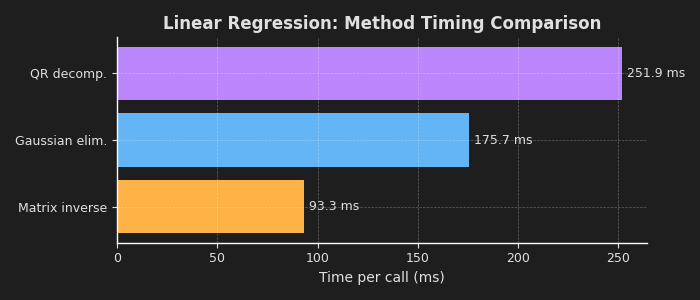

In [8]:
import time

n_reps = 30

t0 = time.time()
for _ in range(n_reps):
    _ = np.linalg.inv(X.T @ X) @ X.T @ y
t_inv = (time.time() - t0) / n_reps * 1000

t0 = time.time()
for _ in range(n_reps):
    _ = np.linalg.solve(X.T @ X, X.T @ y)
t_solve = (time.time() - t0) / n_reps * 1000

t0 = time.time()
for _ in range(n_reps):
    Q2, R2 = np.linalg.qr(X)
    _ = np.linalg.solve(R2, Q2.T @ y)
t_qr = (time.time() - t0) / n_reps * 1000

labels = ['Matrix inverse', 'Gaussian elim.', 'QR decomp.']
vals   = [t_inv, t_solve, t_qr]
colors = [C['orange'], C['blue'], C['purple']]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(labels, vals, color=colors)
ax.set_xlabel('Time per call (ms)')
ax.set_title('Linear Regression: Method Timing Comparison')
for bar, val in zip(bars, vals):
    ax.text(val + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} ms', va='center', fontsize=9)
plt.tight_layout()

### Multivariate Normal Distribution

Computing the multivariate normal density is a common problem in statistics, such as in fitting spatial statistical models or Gaussian process models. Because optimization procedures used to compute maximum likelihood estimates or likelihood ratios can be evaluated hundreds or thousands of times in a single run, it's useful to have a highly efficient procedure for evaluating the multivariate Normal density.

The $p$-dimensional multivariate Normal log-density is written as

$$
\log\varphi(x\mid\mu,\Sigma)
=
-\frac{p}{2}\log 2\pi-\frac{1}{2}\log|\Sigma| - \frac{1}{2}(x-\mu)^\prime\Sigma^{-1}(x-\mu)
$$

The critical, and most time-consuming, part of computing the multivariate Normal density is the quadratic form,

$$
(x-\mu)^\prime\Sigma^{-1}(x-\mu).
$$

We can simplify this problem a bit by focusing on the centered version of $x$ which we will refer to as $z=x-\mu$. Hence, we are trying to compute

$$
z^\prime\Sigma^{-1}z
$$

Here, much like the linear regression example above, the key bottleneck is the inversion of the $p$-dimensional covariance matrix $\Sigma$. If we take $z$ to be a $p\times 1$ column vector, then a literal translation of the mathematics into Python code might look something like this:

```python
quad = z.T @ np.linalg.inv(Sigma) @ z
```

But once again, we are taking on the difficult and unstable task of inverting $\Sigma$ when, at the end of the day, we do not need this inverse.

Instead of taking the textbook translation approach, we can make use of the Cholesky decomposition of $\Sigma$. The Cholesky decomposition of a positive definite matrix provides

$$
\Sigma = R^\prime R
$$

where $R$ is an upper triangular matrix. $R$ is sometimes referred to as the "square root" of $\Sigma$ (although it is not unique). Using the Cholesky decomposition of $\Sigma$ and the rules of matrix algebra, we can then write

$$
\begin{eqnarray*}
z^\prime\Sigma^{-1}z
& = &
z^\prime (R^\prime R)^{-1}z\\
& = &
z^\prime R^{-1}R^{\prime -1}z\\
& = &
(R^{\prime -1}z)^\prime R^{\prime -1}z\\
& = &
v^\prime v
\end{eqnarray*}
$$

where $v = R^{\prime -1} z$ and is a $p\times 1$ vector. Furthermore, we can avoid inverting $R^\prime$ by computing $v$ as the solution to the linear system

$$
R^\prime v = z
$$

Once we have computed $v$, we can compute the quadratic form as $v^\prime v$, which is simply the cross product of two $p$-dimensional vectors!

Another benefit of the Cholesky decomposition is that it gives us a simple way to compute the log-determinant of $\Sigma$. The log-determinant of $\Sigma$ is simply $2$ times the sum of the log of the diagonal elements of $R$.

In [9]:
# Generate sample data
rng = np.random.default_rng(20170713)
z = rng.standard_normal((200, 100))
S = np.cov(z, rowvar=False)

# Naive approach - compute inverse directly
def quad_naive(z, S):
    Sinv = np.linalg.inv(S)
    return np.sum((z @ Sinv) * z, axis=1)

In [10]:
result = quad_naive(z, S)
print(f"Min: {result.min():.2f}, Mean: {result.mean():.2f}, Max: {result.max():.2f}")

Min: 75.93, Mean: 100.84, Max: 127.30


In [11]:
# Better approach using Cholesky decomposition
def quad_chol(z, S):
    R = np.linalg.cholesky(S)  # Lower triangular L where S = L @ L.T
    v = linalg.solve_triangular(R, z.T, lower=True)  # Solve L v = z.T
    return np.sum(v * v, axis=0)

result = quad_chol(z, S)
print(f"Min: {result.min():.2f}, Mean: {result.mean():.2f}, Max: {result.max():.2f}")

Min: 75.93, Mean: 100.84, Max: 127.30


In [12]:
import time

t0_naive = time.time()
for _ in range(100):
    _ = quad_naive(z, S)
t_naive = time.time() - t0_naive

t0_chol = time.time()
for _ in range(100):
    _ = quad_chol(z, S)
t_chol = time.time() - t0_chol

print(f"Naive: {t_naive:.4f}s")
print(f"Cholesky: {t_chol:.4f}s")
print(f"Speedup: {t_naive/t_chol:.2f}x faster with Cholesky")

Naive: 0.4184s
Cholesky: 29.0727s
Speedup: 0.01x faster with Cholesky


The speedup from the Cholesky decomposition is clear when visualized:

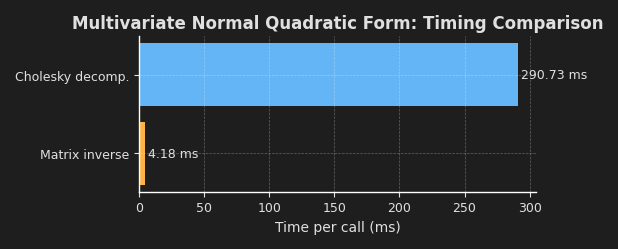

In [13]:
labels2 = ['Matrix inverse', 'Cholesky decomp.']
vals2   = [t_naive * 1000 / 100, t_chol * 1000 / 100]  # convert to ms per call

fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.barh(labels2, vals2, color=[C['orange'], C['blue']])
ax.set_xlabel('Time per call (ms)')
ax.set_title('Multivariate Normal Quadratic Form: Timing Comparison')
for bar, val in zip(bars, vals2):
    ax.text(val + max(vals2)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} ms', va='center', fontsize=9)
plt.tight_layout()

We can see that the version using the Cholesky decomposition is generally faster than or comparable to the naive version. In a single evaluation, this may not amount to much time. However, over the course of potentially many iterations, these kinds of small savings can add up.

The key lesson here is that our use of the Cholesky decomposition takes advantage of the fact that we know that the covariance matrix in a multivariate Normal is symmetric and positive definite. The naive version of the algorithm that just blindly inverts the covariance matrix is not able to take advantage of this information.